# Modeling Plots (Clean Data)

Plots for the Random Forest models across all 5 CO2-pressure targets, computed directly with `mof_models.evaluate_target_columns` and rendered with `src/evaluate.py`. No intermediate CSVs needed — everything is recomputed here from the cleaned dataset.

In [5]:
import sys
import pandas as pd

sys.path.insert(0, "/home/susan/mof-co2-adsorption")
sys.path.insert(0, "/home/susan/mof-co2-adsorption/src")

from mof_models import evaluate_target_columns, split_target_data
from evaluate import plot_parity, plot_residuals, plot_r2_comparison

df = pd.read_csv("/home/susan/mof-co2-adsorption/data/processed/data_clean_v2")

feature_columns = ["lcd", "pld", "void_fraction", "surface_area_m2g"]
target_columns = [
    "CO2_uptake_0.01bar_molkg", "CO2_uptake_0.05bar_molkg",
    "CO2_uptake_0.1bar_molkg", "CO2_uptake_0.5bar_molkg",
    "CO2_uptake_2.5bar_molkg",
]
rf_params = dict(n_estimators=100, max_depth=None, min_samples_split=2,
                  min_samples_leaf=1, max_features="sqrt", random_state=12345, n_jobs=-1)

results, summary = evaluate_target_columns(df, feature_columns, target_columns, rf_params)

# results only stores predictions, so rebuild the matching actual-value splits
y_true_by_target = {}
for target in target_columns:
    X_train, X_valid, X_test, y_train, y_valid, y_test = split_target_data(df, feature_columns, target)
    y_true_by_target[target] = {"train": y_train, "valid": y_valid, "test": y_test}

summary

,target,train_mae,train_rmse,train_r2,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2,train_valid_r2_gap,valid_test_r2_gap
0,CO2_uptake_0.01bar_molkg,0.029280,0.064282,0.918881,0.081188,0.172762,0.407475,0.078342,0.162153,0.432744,0.511407,-0.025269
1,CO2_uptake_0.05bar_molkg,0.078663,0.133659,0.936621,0.220690,0.370287,0.528044,0.218981,0.365307,0.537736,0.408577,-0.009692
2,CO2_uptake_0.1bar_molkg,0.115834,0.181014,0.940489,0.323709,0.497419,0.562646,0.322208,0.499722,0.570212,0.377843,-0.007566
3,CO2_uptake_0.5bar_molkg,0.247628,0.344877,0.942641,0.689511,0.948472,0.590292,0.680890,0.933244,0.604772,0.352349,-0.014480
4,CO2_uptake_2.5bar_molkg,0.430779,0.587178,0.946742,1.163692,1.550202,0.640735,1.167831,1.573456,0.618470,0.306007,0.022264


## Actual vs. predicted (parity plots)

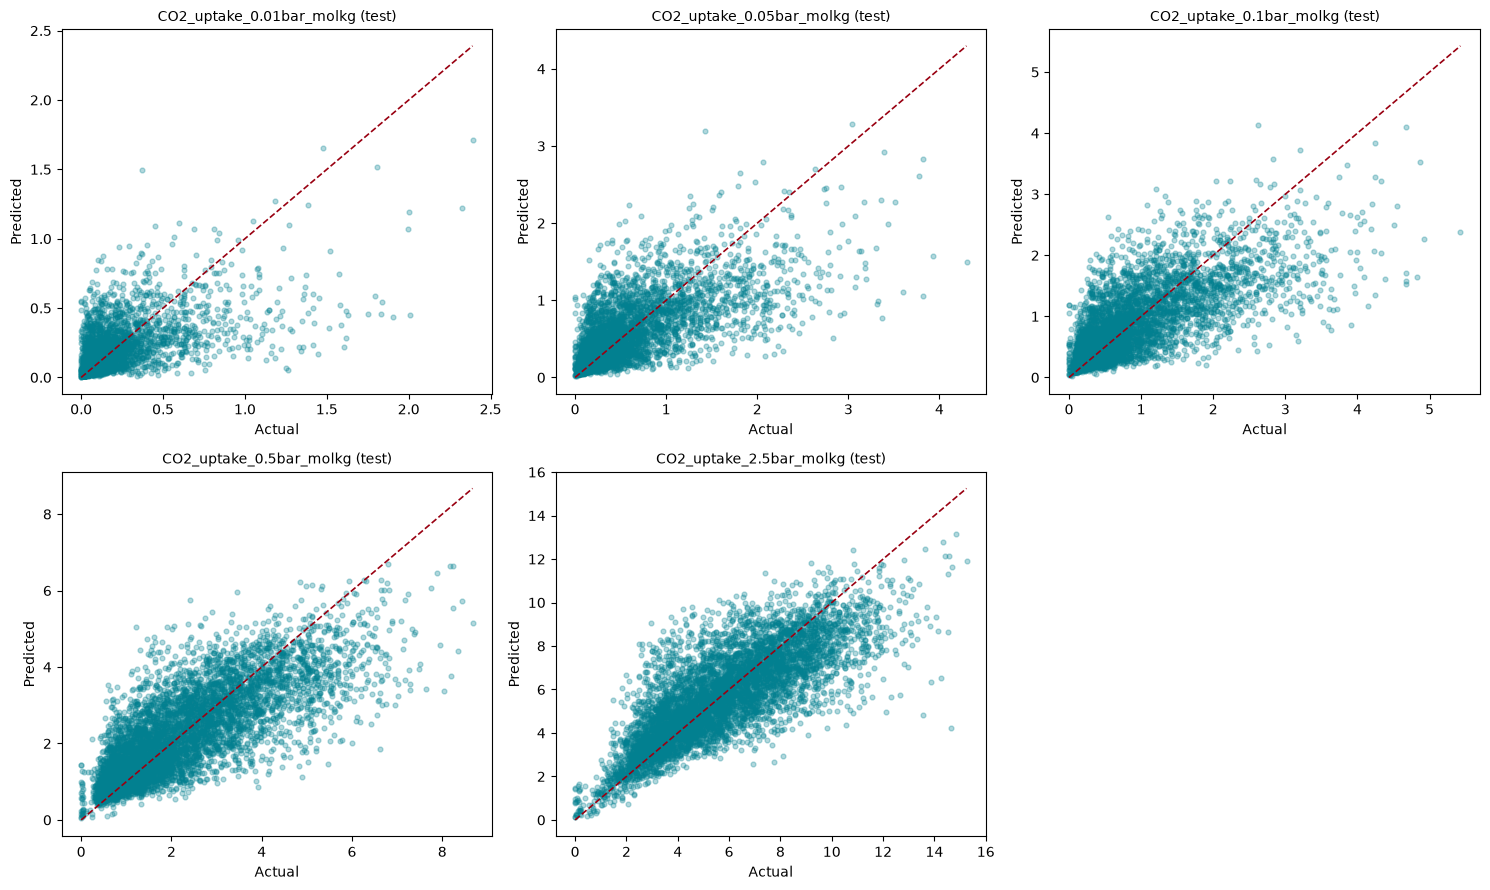

In [2]:
fig = plot_parity(results, y_true_by_target, split="test")

**1. Actual vs Predicted**| How accurately does the model reproduce actual CO₂ uptake?  

The actual-versus-predicted plots show improved model performance as pressure increases. At 0.01 bar, the predictions are more scattered relative to the ideal line, with overprediction occurring for some low-uptake MOFs and substantial underprediction for many higher-uptake MOFs. In contrast, at 2.5 bar, the predictions follow the ideal line more closely across the uptake range, indicating stronger agreement between predicted and actual CO₂ uptake. Although the spread increases at higher uptake values, predictions occur on both sides of the ideal line. Overall, the structural descriptors provide better predictive performance at high pressure than at very low pressure.

| Plot                                | Question should learn to answer                           |
| ----------------------------------- | ------------------------------------------------------------- |
| **1. Actual vs Predicted**          | How accurately does the model reproduce actual CO₂ uptake?    |
| **2. Residual vs Predicted**        | Is the model making systematic errors?                        |
| **3. Residual distribution**        | Are errors centered around zero? Are there large-error tails? |
| **4. Train / Validation / Test R²** | Is the model overfitting, and does it generalize?             |
| **5. Pressure comparison**          | Does model performance change from low → high pressure?     

## Residuals

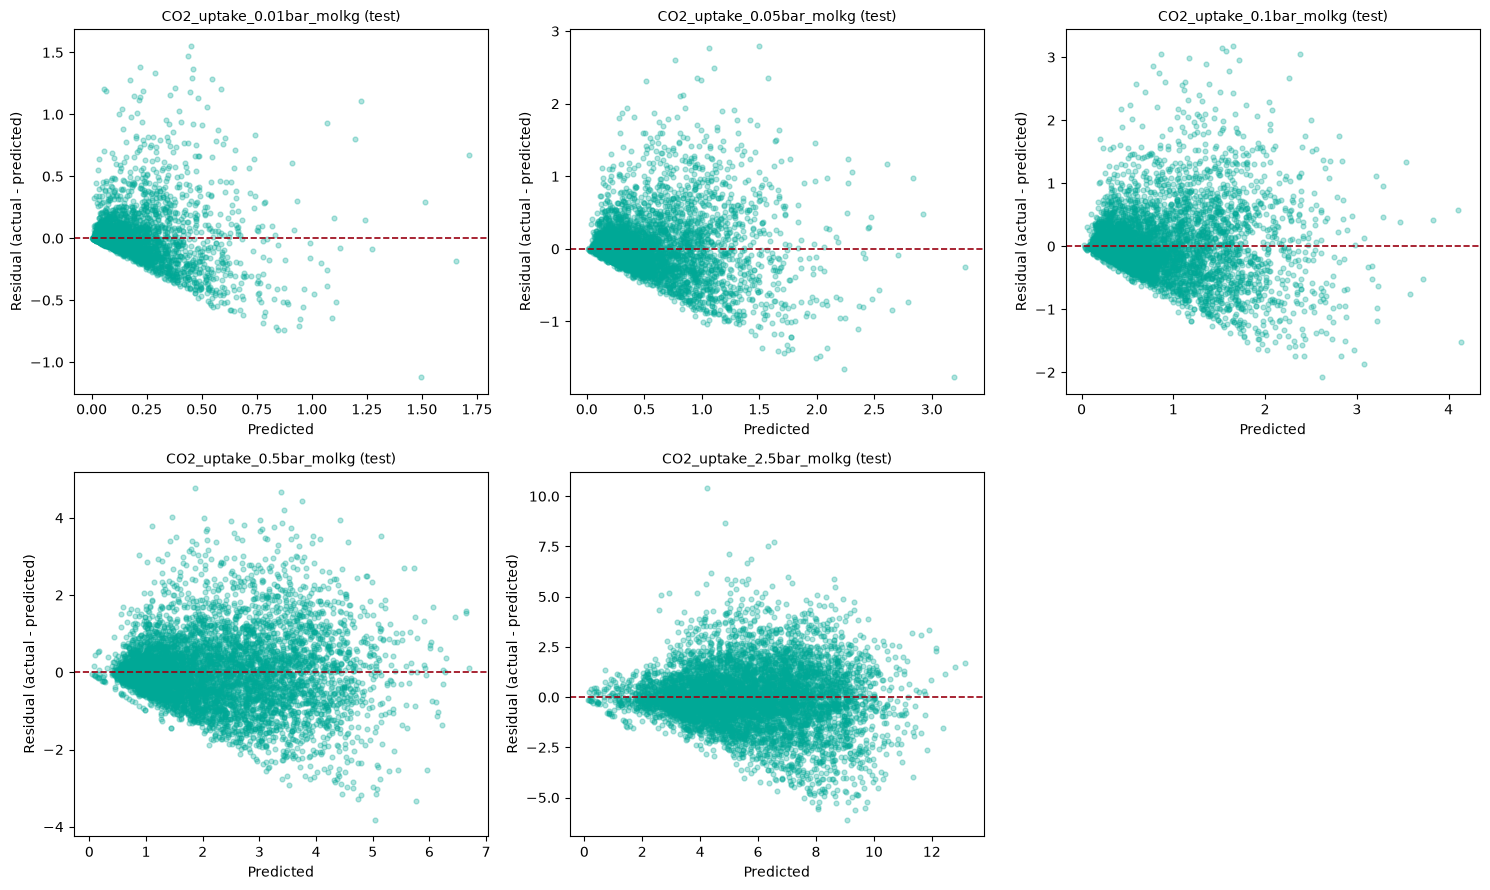

In [3]:
fig = plot_residuals(results, y_true_by_target, split="test")

**2. Residual vs Predicted**| Is the model making systematic errors?  
**3. Residual distribution**        | Are errors centered around zero? Are there large-error tails? 
``` text 
Residual=Actual−Predicted
Therefore:

Residual = 0 → perfect prediction.
Positive residual → actual > predicted → underprediction.
Negative residual → actual < predicted → overprediction.

Across all pressures, residuals occur both above and below zero, indicating both underprediction and overprediction. However, the residual spread increases as predicted CO₂ uptake increases, producing a fan-shaped pattern. This indicates that prediction errors are smaller for low-uptake MOFs and become more variable for higher-uptake MOFs. The pattern persists across pressure levels, suggesting that the model has greater difficulty accurately predicting some high-uptake structures.
``` 

## Train / valid / test R² comparison

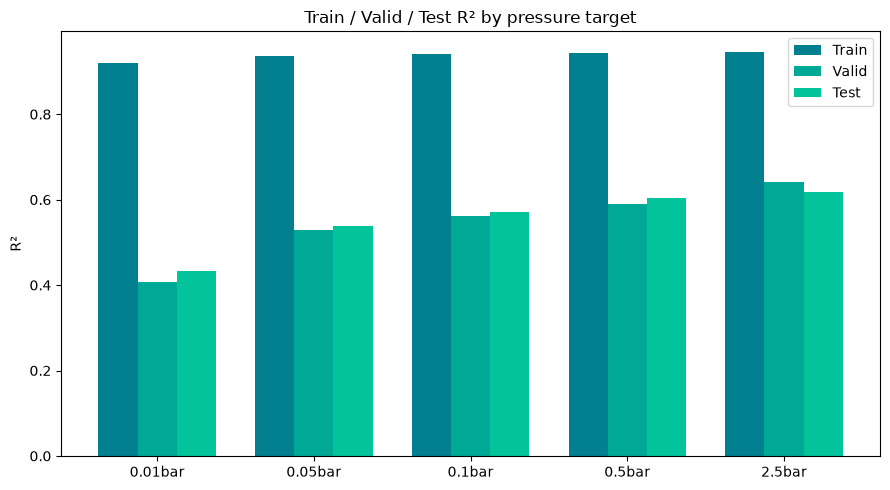

In [4]:
fig = plot_r2_comparison(summary)

**4. Train / Validation / Test R²** | Is the model overfitting, and does it generalize?   
Question: Is the model overfitting, and does it generalize?

Validation and test R² are very close at all five pressures, indicating that validation performance is reasonably consistent with final test performance.

At 0.01 bar, validation/test R² are approximately 0.41–0.43, while at 2.5 bar they increase to approximately 0.62–0.64.

The increasing validation and test R² with pressure suggests that the four structural descriptors capture CO₂ adsorption behavior more effectively at higher pressure. At very low pressure, the lower R² indicates that these structural features alone are insufficient to explain much of the adsorption variability, suggesting that additional descriptors—particularly chemistry-related features—may be needed.

However, training R² remains above 0.90 at all pressures and is substantially higher than validation/test R², indicating that the Random Forest still shows some overfitting.

## Combined interpretation
The diagnostic plots show that the Random Forest reproduces CO₂ uptake more accurately at lower uptake values and shows stronger overall predictive performance as pressure increases. The actual-versus-predicted plots show better agreement between predicted and actual uptake at higher pressures. The residual plots show that prediction errors become more variable as CO₂ uptake increases, indicating greater difficulty predicting high-uptake MOFs. Consistent with these observations, validation and test R² increase with pressure, suggesting that the four structural descriptors are more predictive of CO₂ adsorption at higher pressures. However, the substantially higher training R² compared with validation and test R² indicates some overfitting.